In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [45]:

appo_df = pd.read_csv('apollo_appointments_fact.csv')
doc_df = pd.read_csv('apollo_doctors_dim.csv')



In [63]:

none_cols = ['patient_chronic_condition', 'membership_type', 'insurance_provider', 'cancellation_reason']
for col in none_cols:
    appo_df[col] = appo_df[col].fillna('None')



In [48]:

df_merged = pd.merge(appo_df, doc_df, on='doctor_id', how='left')


In [49]:
resolved_df = df_merged[df_merged['appointment_status'] != 'Scheduled'].copy()
completed_df = df_merged[df_merged['appointment_status'] == 'Completed'].copy()


print(f"Total Appointments : {resolved_df.shape[0]}")
print(f"Total Completed Appointments : {completed_df.shape[0]}")



Total Appointments : 72652
Total Completed Appointments : 55275


In [50]:
appo_df


,appointment_id,patient_id,doctor_id,appointment_date,appointment_day,appointment_day_of_week,appointment_month,appointment_quarter,appointment_year,appointment_hour,...,insurance_coverage,insurance_provider,insurance_covered_amount,patient_out_of_pocket,revenue_realized,payment_mode,wait_time_minutes,consultation_duration_min,patient_satisfaction_score,doctor_utilization_pct
0,APPT5000001,PAT117608,DOC1035,2023-11-15,Wednesday,2,11,Q4,2023,15,...,No,None,0,2700,2700,UPI,11.0,40.0,4.8,84.2
1,APPT5000002,PAT128732,DOC1049,2023-03-13,Monday,0,3,Q1,2023,9,...,No,None,0,1400,1400,UPI,21.0,18.0,4.1,64.5
2,APPT5000003,PAT137532,DOC1033,2022-02-07,Monday,0,2,Q1,2022,17,...,No,None,0,600,600,Net Banking,6.0,6.0,5.0,75.6
3,APPT5000004,PAT113284,DOC1288,2023-11-20,Monday,0,11,Q4,2023,17,...,No,None,0,1275,1275,UPI,2.0,25.0,4.4,68.6
4,APPT5000005,PAT107443,DOC1064,2024-02-02,Friday,4,2,Q1,2024,19,...,No,None,0,1700,1700,Cash,7.0,13.0,3.5,67.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,APPT5074996,PAT124687,DOC1215,2024-02-04,Sunday,6,2,Q1,2024,16,...,No,None,0,700,700,Credit Card,0.0,27.0,4.2,78.4
74996,APPT5074997,PAT135901,DOC1236,2022-03-18,Friday,4,3,Q1,2022,9,...,No,None,0,1020,1020,Debit Card,4.0,26.0,3.7,72.2
74997,APPT5074998,PAT123568,DOC1163,2022-08-16,Tuesday,1,8,Q3,2022,9,...,Yes,HDFC ERGO,2517,383,383,Insurance,0.0,22.0,2.9,84.5
74998,APPT5074999,PAT123394,DOC1278,2024-09-09,Monday,0,9,Q3,2024,10,...,Yes,Niva Bupa,1267,133,133,Insurance,19.0,30.0,3.8,79.1


In [51]:

duplicates = appo_df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")



Total Duplicate Rows: 0


In [52]:

appo_df['appointment_date'] = pd.to_datetime(appo_df['appointment_date'])
appo_df['booking_date'] = pd.to_datetime(appo_df['booking_date'])
print("Dates successfully converted to Datetime object!")


Dates successfully converted to Datetime object!


In [53]:

missing_data = appo_df.isnull().sum()
print(missing_data[missing_data > 0].sort_values(ascending=False))

wait_time_minutes             19725
consultation_duration_min     19725
patient_satisfaction_score    19725
doctor_utilization_pct        19725
no_show                        2348
dtype: int64


=== Appointment Volume by Quarter ===
2022-Q1    6523
2022-Q2    5782
2022-Q3    5783
2022-Q4    6780
2023-Q1    6487
2023-Q2    5862
2023-Q3    5707
2023-Q4    6998
2024-Q1    6538
2024-Q2    5899
2024-Q3    5777
2024-Q4    6864
Name: appointment_id, dtype: int64


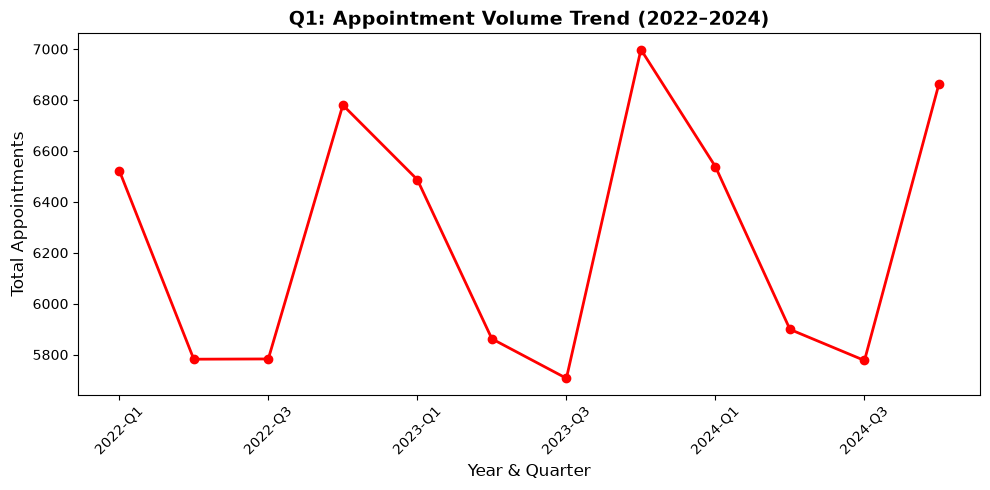

In [54]:
# ============================================================
# QUESTION 1: How is appointment volume trending across
# months and quarters from 2022 to 2024?
# ============================================================


trend_data = (
    appo_df
    .groupby(['appointment_year', 'appointment_quarter'])['appointment_id']
    .count()
)


trend_data.index = [
    f"{year}-{quarter}"
    for year, quarter in trend_data.index
]


print("=== Appointment Volume by Quarter ===")
print(trend_data)



import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

trend_data.plot(
    kind='line',
    marker='o',
    color='red',
    linewidth=2
)

plt.title(
    'Q1: Appointment Volume Trend (2022–2024)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year & Quarter', fontsize=12)
plt.ylabel('Total Appointments', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()





--- Outcome Split (%) ---
appointment_status
Completed    73.70
No-Show      15.45
Cancelled     7.72
Scheduled     3.13
Name: proportion, dtype: float64


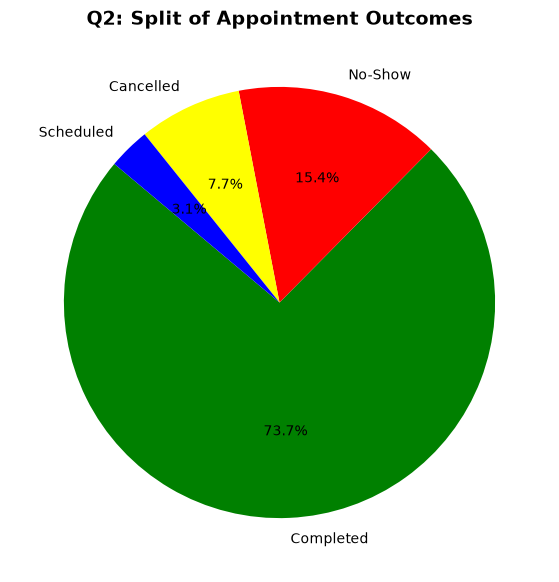

In [57]:
# ====================================================
# QUESTION 2: What is the split of outcomes across completed, no-show, cancelled, and scheduled appointments?
# ====================================================

outcome_counts = appo_df['appointment_status'].value_counts()
outcome_percentages = appo_df['appointment_status'].value_counts(normalize=True) * 100

print("--- Outcome Split (%) ---")
print(outcome_percentages.round(2))



plt.figure(figsize=(7, 7)) 
outcome_counts.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=140,  
    colors=['Green', 'Red', 'Yellow', 'Blue'] )


plt.title('Q2: Split of Appointment Outcomes', fontsize=14, fontweight='bold')
plt.ylabel('')


plt.show()

--- Booking Channel Volume & Mix (%) ---
                 Total Volume  Mix (%)
booking_channel                       
Apollo App              34042    45.39
Website                 18545    24.73
Call Centre             11201    14.93
Walk-In                  7501    10.00
Partner App              3711     4.95


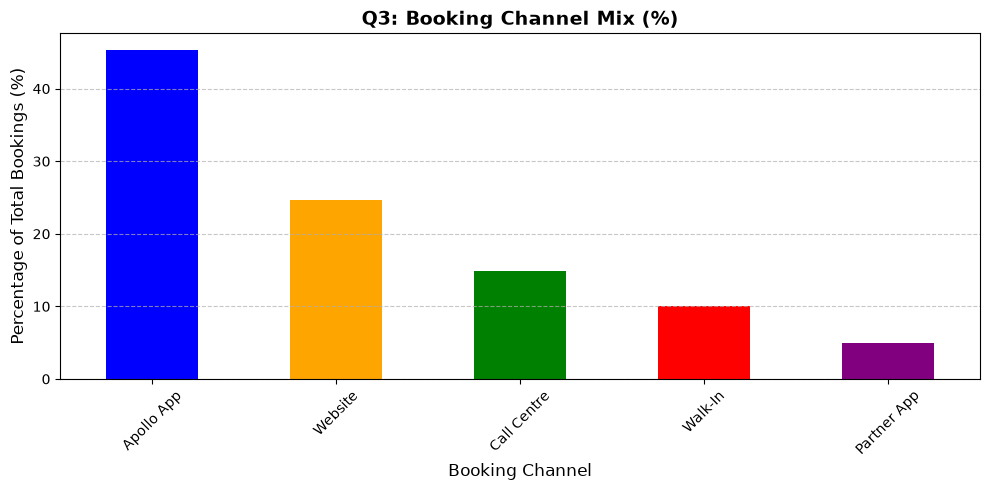

In [59]:
# ====================================================
# QUESTION 3: Which booking channels drive the highest volume and how does the channel mix look?
# ====================================================

channel_volume = appo_df['booking_channel'].value_counts()
channel_mix = appo_df['booking_channel'].value_counts(normalize=True) * 100

print("--- Booking Channel Volume & Mix (%) ---")

channel_summary = pd.DataFrame({
    'Total Volume': channel_volume,
    'Mix (%)': channel_mix.round(2)
})
print(channel_summary)




plt.figure(figsize=(10, 5)) 
channel_mix.plot(
    kind='bar', 
    color=['blue', 'orange', 'green', 'red', 'purple'] 
)


plt.title('Q3: Booking Channel Mix (%)', fontsize=14, fontweight='bold')
plt.xlabel('Booking Channel', fontsize=12)
plt.ylabel('Percentage of Total Bookings (%)', fontsize=12)
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()

--- Highest & Lowest No-Show Rates by Specialty (%) ---
Highest:
 specialty_x
Psychiatry     24.52
Dermatology    21.25
ENT            18.96
Name: no_show_flag, dtype: float64

Lowest:
 specialty_x
Cardiology     14.03
Paediatrics    12.22
Neurology      10.69
Name: no_show_flag, dtype: float64

--- Highest & Lowest No-Show Rates by City (%) ---
Highest:
 city_x
Lucknow    17.19
Mumbai     17.04
Delhi      16.86
Name: no_show_flag, dtype: float64

Lowest:
 city_x
Coimbatore    14.15
Indore        14.15
Pune          13.30
Name: no_show_flag, dtype: float64


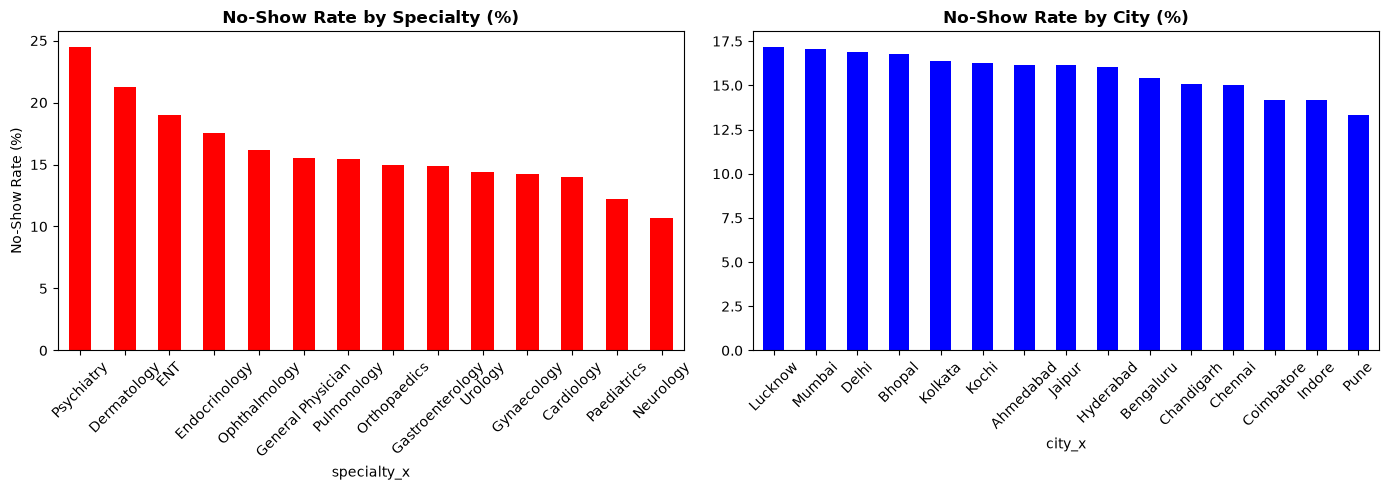

In [ ]:
# ====================================================
# SECTION 2: NO-SHOW ANALYSIS
# QUESTION 1: Which specialties and cities have the highest and lowest no-show rates?
# ====================================================


resolved_df = df_merged[df_merged['appointment_status'] != 'Scheduled'].copy()

specialty_noshow = resolved_df.groupby('specialty_x')['no_show_flag'].mean() * 100
specialty_noshow = specialty_noshow.sort_values(ascending=False)


city_noshow = resolved_df.groupby('city_x')['no_show_flag'].mean() * 100
city_noshow = city_noshow.sort_values(ascending=False)

print("--- Highest & Lowest No-Show Rates by Specialty (%) ---")
print("Highest:\n", specialty_noshow.head(3).round(2))
print("\nLowest:\n", specialty_noshow.tail(3).round(2))

print("\n--- Highest & Lowest No-Show Rates by City (%) ---")
print("Highest:\n", city_noshow.head(3).round(2))
print("\nLowest:\n", city_noshow.tail(3).round(2))



import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 


specialty_noshow.plot(kind='bar', color='red', ax=axes[0])
axes[0].set_title('No-Show Rate by Specialty (%)', fontweight='bold')
axes[0].set_ylabel('No-Show Rate (%)')
axes[0].tick_params(axis='x', rotation=45)


city_noshow.plot(kind='bar', color='blue', ax=axes[1])
axes[1].set_title('No-Show Rate by City (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

--- Key Insights: No-Show Probability by Lead Time ---
Same-day booking (0 days): 15.82%
1 Week advance (7 days):   18.77%
30 Days advance (30 days): 23.26%


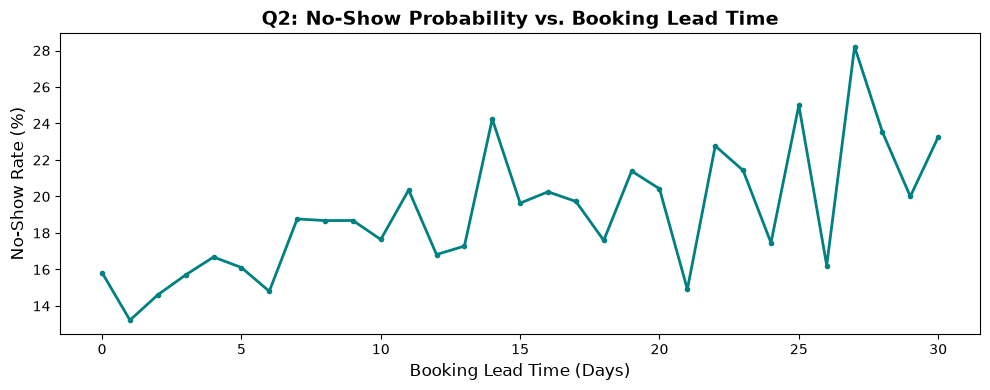

In [61]:
# ====================================================
# SECTION 2: NO-SHOW ANALYSIS
# QUESTION 2: How does booking lead time affect the probability of a no-show?
# ====================================================


lead_time_noshow = resolved_df.groupby('booking_lead_days')['no_show_flag'].mean() * 100

print("--- Key Insights: No-Show Probability by Lead Time ---")
print(f"Same-day booking (0 days): {lead_time_noshow[0].round(2)}%")
print(f"1 Week advance (7 days):   {lead_time_noshow[7].round(2)}%")
print(f"30 Days advance (30 days): {lead_time_noshow[30].round(2)}%")



plt.figure(figsize=(10, 4)) 
lead_time_noshow.plot(
    kind='line', 
    marker='.',       
    color='teal',     
    linewidth=2
)


plt.title('Q2: No-Show Probability vs. Booking Lead Time', fontsize=14, fontweight='bold')
plt.xlabel('Booking Lead Time (Days)', fontsize=12)
plt.ylabel('No-Show Rate (%)', fontsize=12)


plt.tight_layout()
plt.show()

In [ ]:
# ====================================================
# SECTION 2: NO-SHOW ANALYSIS
# QUESTION 3: Do evening slots, weekends, and longer-lead bookings see higher dropout?
# ====================================================



time_noshow = resolved_df.groupby('time_of_day')['no_show_flag'].mean() * 100


resolved_df['is_weekend'] = np.where(resolved_df['appointment_day_of_week'] >= 5, 'Weekend', 'Weekday')
weekend_noshow = resolved_df.groupby('is_weekend')['no_show_flag'].mean() * 100


resolved_df['lead_bucket'] = 'Long Lead (8+ Days)' 
resolved_df.loc[resolved_df['booking_lead_days'] == 0, 'lead_bucket'] = 'Same Day (0 Days)' 
resolved_df.loc[(resolved_df['booking_lead_days'] >= 1) & (resolved_df['booking_lead_days'] <= 7), 'lead_bucket'] = 'Short Lead (1-7 Days)' 

lead_bucket_noshow = resolved_df.groupby('lead_bucket')['no_show_flag'].mean() * 100



print("--- 1. No-Show Rate by Time of Day (%) ---")
print(time_noshow.round(2).sort_values(ascending=False))

print("\n--- 2. No-Show Rate by Weekday vs Weekend (%) ---")
print(weekend_noshow.round(2).sort_values(ascending=False))

print("\n--- 3. No-Show Rate by Booking Lead Time Bucket (%) ---")
print(lead_bucket_noshow.round(2).sort_values(ascending=False))

print("\n(Note: No chart is needed here because the text comparison is clear enough!)")

--- 1. No-Show Rate by Time of Day (%) ---
time_of_day
Evening      18.37
Afternoon    17.75
Morning      13.73
Name: no_show_flag, dtype: float64

--- 2. No-Show Rate by Weekday vs Weekend (%) ---
is_weekend
Weekend    18.68
Weekday    14.84
Name: no_show_flag, dtype: float64

--- 3. No-Show Rate by Booking Lead Time Bucket (%) ---
lead_bucket
Long Lead (8+ Days)      19.07
Same Day (0 Days)        15.82
Short Lead (1-7 Days)    15.16
Name: no_show_flag, dtype: float64

(Note: No chart is needed here because the text comparison is clear enough!)


--- No-Show Risk by Appointment Type (%) ---
appointment_type
Home Visit       26.25
Video Consult    21.06
In-Clinic        12.18
Name: no_show_flag, dtype: float64

--- No-Show Risk by Booking Channel (%) ---
booking_channel
Walk-In        20.88
Partner App    18.11
Website        17.20
Call Centre    15.20
Apollo App     14.18
Name: no_show_flag, dtype: float64


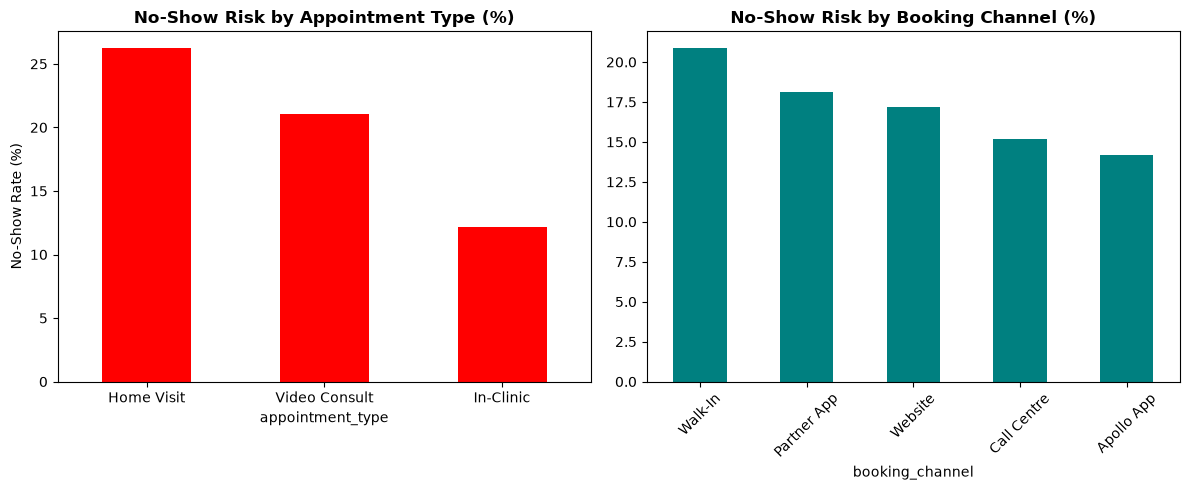

In [64]:
# ====================================================
# SECTION 2: NO-SHOW ANALYSIS
# QUESTION 4: Which appointment types and booking channels carry the most no-show risk?
# ====================================================


type_noshow = resolved_df.groupby('appointment_type')['no_show_flag'].mean() * 100
type_noshow = type_noshow.sort_values(ascending=False)


channel_noshow = resolved_df.groupby('booking_channel')['no_show_flag'].mean() * 100
channel_noshow = channel_noshow.sort_values(ascending=False)

print("--- No-Show Risk by Appointment Type (%) ---")
print(type_noshow.round(2))

print("\n--- No-Show Risk by Booking Channel (%) ---")
print(channel_noshow.round(2))



fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 


type_noshow.plot(kind='bar', color='red', ax=axes[0])
axes[0].set_title('No-Show Risk by Appointment Type (%)', fontweight='bold')
axes[0].set_ylabel('No-Show Rate (%)')
axes[0].tick_params(axis='x', rotation=0) 


channel_noshow.plot(kind='bar', color='teal', ax=axes[1]) # Orange color
axes[1].set_title('No-Show Risk by Booking Channel (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout()

plt.show()

--- No-Show Rate by Reminder Type (%) ---
reminder_type
No Reminder              30.16
SMS Only                 16.27
SMS + WhatsApp           13.51
SMS + WhatsApp + Call    11.41
Name: no_show_flag, dtype: float64


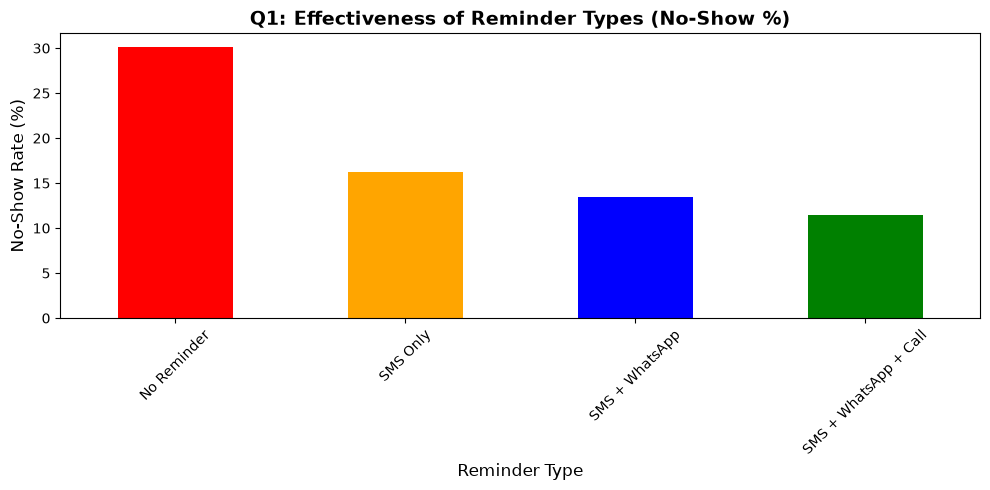

In [66]:
# ====================================================
# SECTION 3: REMINDER & ENGAGEMENT EFFECTIVENESS
# QUESTION 1: How much does reminder type reduce no-show rates compared to no-reminder patients?
# ====================================================

reminder_noshow = resolved_df.groupby('reminder_type')['no_show_flag'].mean() * 100


reminder_noshow = reminder_noshow.sort_values(ascending=False)

print("--- No-Show Rate by Reminder Type (%) ---")
print(reminder_noshow.round(2))


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5)) # Set chart size

reminder_noshow.plot(
    kind='bar', 
    color=['red', 'orange', 'blue', 'green', 'black'] 
)

plt.title('Q1: Effectiveness of Reminder Types (No-Show %)', fontsize=14, fontweight='bold')
plt.xlabel('Reminder Type', fontsize=12)
plt.ylabel('No-Show Rate (%)', fontsize=12)
plt.xticks(rotation=45) 


plt.tight_layout()

plt.show()

--- No-Show Rate Based on Prior History (%) ---
prior_noshow_bucket
0 Prior No-Shows     15.15
1 Prior No-Show      20.27
2 Prior No-Shows     26.65
3+ Prior No-Shows    32.68
Name: no_show_flag, dtype: float64


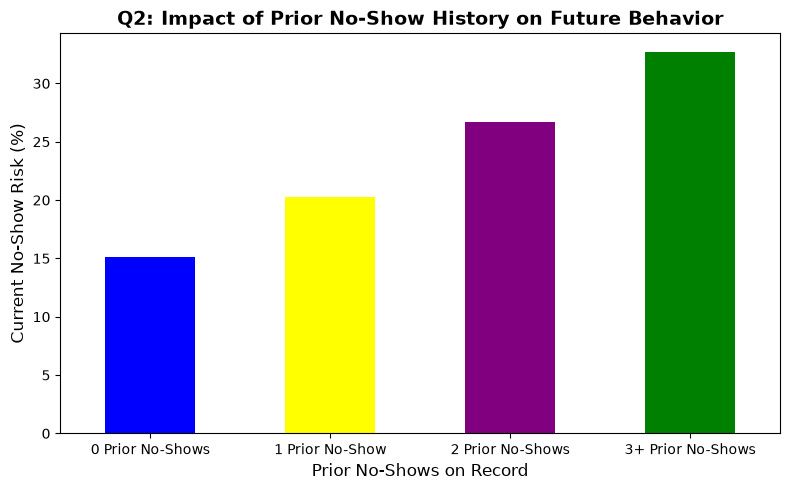

In [68]:

# ====================================================
# SECTION 3: REMINDER & ENGAGEMENT EFFECTIVENESS
# QUESTION 2: Does prior no-show history predict future no-show behaviour?
# ====================================================

resolved_df['prior_noshow_bucket'] = '3+ Prior No-Shows' 
resolved_df.loc[resolved_df['patient_prior_no_shows'] == 0, 'prior_noshow_bucket'] = '0 Prior No-Shows'
resolved_df.loc[resolved_df['patient_prior_no_shows'] == 1, 'prior_noshow_bucket'] = '1 Prior No-Show'
resolved_df.loc[resolved_df['patient_prior_no_shows'] == 2, 'prior_noshow_bucket'] = '2 Prior No-Shows'


history_noshow = resolved_df.groupby('prior_noshow_bucket')['no_show_flag'].mean() * 100


history_noshow = history_noshow.reindex(['0 Prior No-Shows', '1 Prior No-Show', '2 Prior No-Shows', '3+ Prior No-Shows'])

print("--- No-Show Rate Based on Prior History (%) ---")
print(history_noshow.round(2))



import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5)) 
history_noshow.plot(
    kind='bar', 
    color=['blue', 'yellow', 'purple', 'green'] # Colors changing from green (safe) to red (danger)
)

# Decorate the chart
plt.title('Q2: Impact of Prior No-Show History on Future Behavior', fontsize=14, fontweight='bold')
plt.xlabel('Prior No-Shows on Record', fontsize=12)
plt.ylabel('Current No-Show Risk (%)', fontsize=12)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()


--- No-Show Rate: Apollo Members vs Non-Members (%) ---
apollo_member
No     16.89
Yes    12.66
Name: no_show_flag, dtype: float64

--- No-Show Rate: Repeat vs First-Time Patients (%) ---
repeat_visit
No     66.78
Yes     8.59
Name: no_show_flag, dtype: float64


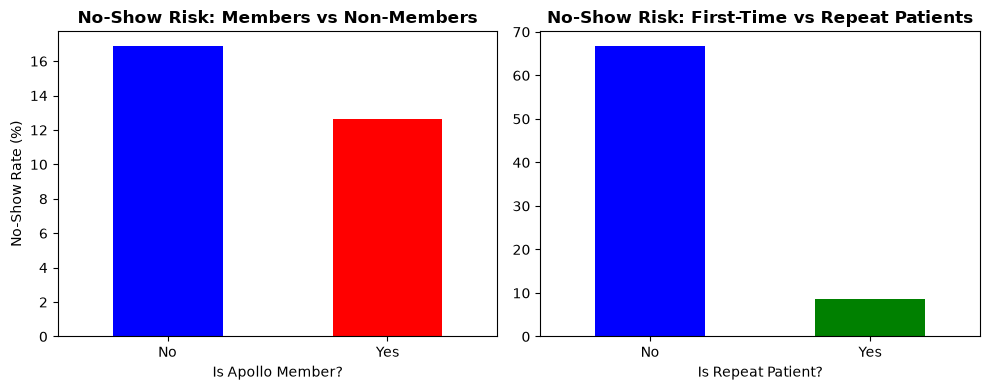

In [69]:
# ====================================================
# SECTION 3: REMINDER & ENGAGEMENT EFFECTIVENESS
# QUESTION 3: Do Apollo members and repeat patients show better attendance than non-members and first-time patients?
# ====================================================

member_noshow = resolved_df.groupby('apollo_member')['no_show_flag'].mean() * 100

visit_noshow = resolved_df.groupby('repeat_visit')['no_show_flag'].mean() * 100

print("--- No-Show Rate: Apollo Members vs Non-Members (%) ---")
print(member_noshow.round(2))

print("\n--- No-Show Rate: Repeat vs First-Time Patients (%) ---")
print(visit_noshow.round(2))


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4)) 


member_noshow.plot(kind='bar', color=['blue', 'red'], ax=axes[0]) 
axes[0].set_title('No-Show Risk: Members vs Non-Members', fontweight='bold')
axes[0].set_ylabel('No-Show Rate (%)')
axes[0].set_xlabel('Is Apollo Member?')
axes[0].tick_params(axis='x', rotation=0)


visit_noshow.plot(kind='bar', color=['blue', 'green'], ax=axes[1])
axes[1].set_title('No-Show Risk: First-Time vs Repeat Patients', fontweight='bold')
axes[1].set_xlabel('Is Repeat Patient?')
axes[1].tick_params(axis='x', rotation=0)


plt.tight_layout()
plt.show()

--- Data calculated successfully for Age, Gender, and Chronic Conditions! ---


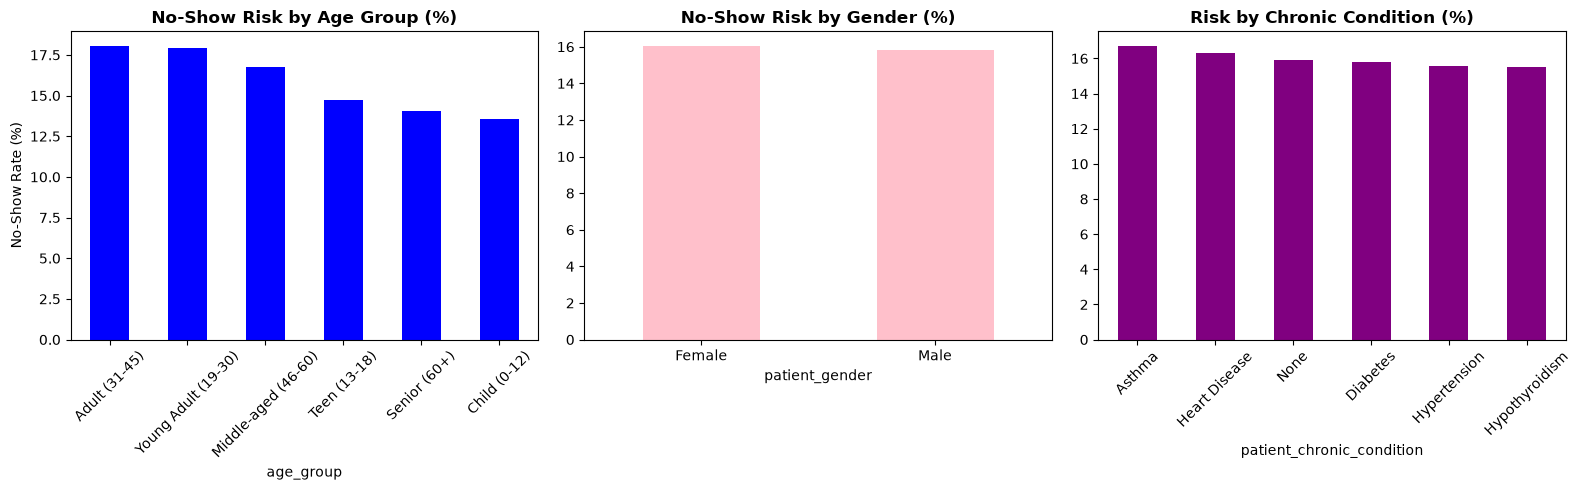

In [70]:
# ====================================================
# SECTION 4: PATIENT AND DEMOGRAPHIC SEGMENTATION
# QUESTION 1: How do age group, gender, and chronic condition status influence no-show likelihood?
# ====================================================

age_noshow = resolved_df.groupby('age_group')['no_show_flag'].mean() * 100
age_noshow = age_noshow.sort_values(ascending=False)


gender_noshow = resolved_df.groupby('patient_gender')['no_show_flag'].mean() * 100
gender_noshow = gender_noshow.sort_values(ascending=False)


chronic_noshow = resolved_df.groupby('patient_chronic_condition')['no_show_flag'].mean() * 100
chronic_noshow = chronic_noshow.sort_values(ascending=False)

print("--- Data calculated successfully for Age, Gender, and Chronic Conditions! ---")


fig, axes = plt.subplots(1, 3, figsize=(16, 5)) 

age_noshow.plot(kind='bar', color='blue', ax=axes[0]) # Blue
axes[0].set_title('No-Show Risk by Age Group (%)', fontweight='bold')
axes[0].set_ylabel('No-Show Rate (%)')
axes[0].tick_params(axis='x', rotation=45)


gender_noshow.plot(kind='bar', color='pink', ax=axes[1])
axes[1].set_title('No-Show Risk by Gender (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)


chronic_noshow.plot(kind='bar', color='purple', ax=axes[2])
axes[2].set_title('Risk by Chronic Condition (%)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

--- Top 5 Most Common Visit Reasons ---
visit_reason
Follow-up                       8528
Routine Checkup                 8377
Chronic Condition Management    8117
Digestive Problem               7984
Fever & Infection               6808
Name: count, dtype: int64

--- Top 5 Visit Reasons with HIGHEST Dropout Rate (%) ---
visit_reason
Skin Issue           16.79
Joint Pain           16.73
Cardiac Concern      16.29
Mental Health        16.28
Digestive Problem    16.24
Name: no_show_flag, dtype: float64


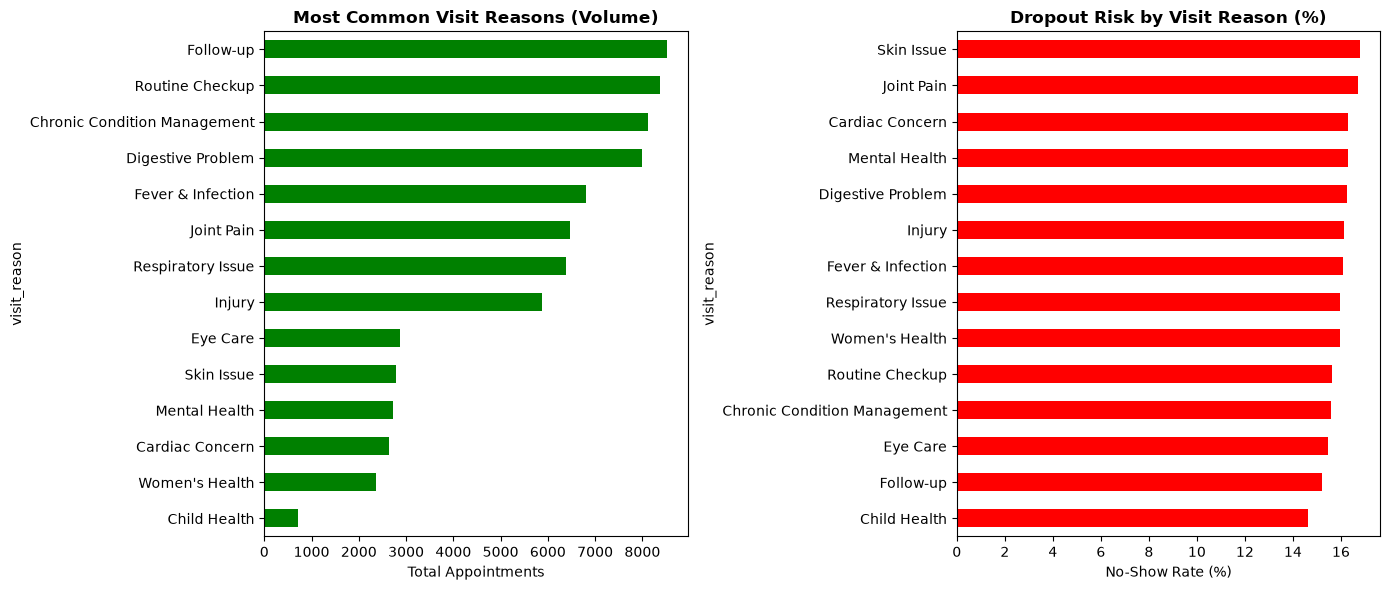

In [ ]:
# ====================================================
# SECTION 4: PATIENT AND DEMOGRAPHIC SEGMENTATION
# QUESTION 2: Which visit reasons are most common and are some associated with higher dropout?
# ====================================================


visit_volume = resolved_df['visit_reason'].value_counts()


visit_noshow = resolved_df.groupby('visit_reason')['no_show_flag'].mean() * 100
visit_noshow = visit_noshow.sort_values(ascending=True) 

print("--- Top 5 Most Common Visit Reasons ---")
print(visit_volume.head())

print("\n--- Top 5 Visit Reasons with HIGHEST Dropout Rate (%) ---")
print(visit_noshow.tail().sort_values(ascending=False).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

visit_volume.sort_values().plot(kind='barh', color='green', ax=axes[0]) 
axes[0].set_title('Most Common Visit Reasons (Volume)', fontweight='bold')
axes[0].set_xlabel('Total Appointments')


visit_noshow.plot(kind='barh', color='red', ax=axes[1]) 
axes[1].set_title('Dropout Risk by Visit Reason (%)', fontweight='bold')
axes[1].set_xlabel('No-Show Rate (%)')

plt.tight_layout()
plt.show()

--- Age Group Distribution by Specific Specialties (%) ---
age_group    Adult (31-45)  Child (0-12)  Middle-aged (46-60)  Senior (60+)  \
specialty_x                                                                   
Gynaecology          23.45         11.78                21.62         22.35   
Paediatrics           0.00         68.28                 0.00          0.00   
Psychiatry           22.38         10.90                22.34         23.10   

age_group    Teen (13-18)  Young Adult (19-30)  
specialty_x                                     
Gynaecology          6.21                14.58  
Paediatrics         31.72                 0.00  
Psychiatry           7.00                14.28  


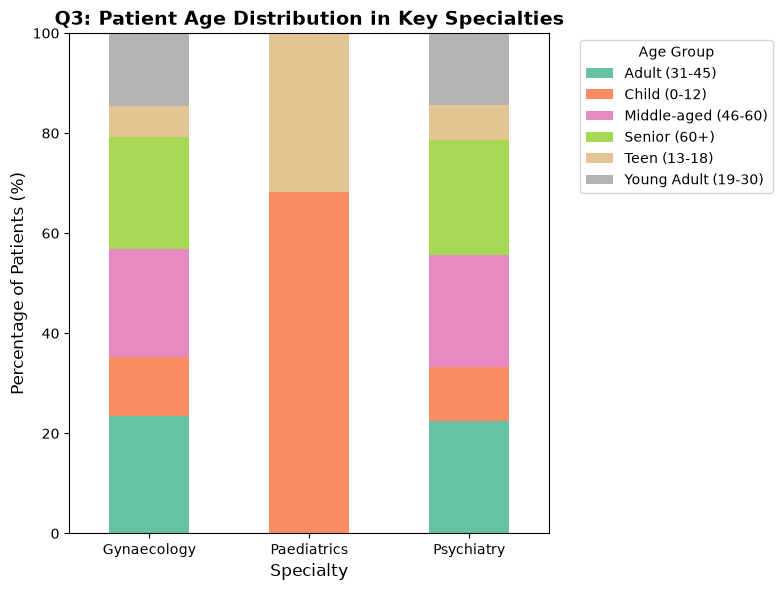

In [74]:
# ====================================================
# SECTION 4: PATIENT AND DEMOGRAPHIC SEGMENTATION
# QUESTION 3: What does the patient age distribution look like within specialties like Paediatrics, Gynaecology, and Psychiatry?
# ====================================================

target_specialties = ['Paediatrics', 'Gynaecology', 'Psychiatry']


filtered_df = resolved_df[resolved_df['specialty_x'].isin(target_specialties)]


age_specialty_mix = pd.crosstab(
    filtered_df['specialty_x'], 
    filtered_df['age_group'], 
    normalize='index' 
) * 100

print("--- Age Group Distribution by Specific Specialties (%) ---")
print(age_specialty_mix.round(2))

age_specialty_mix.plot(
    kind='bar', 
    stacked=True, 
    colormap='Set2', 
    figsize=(8, 6)
)

plt.title('Q3: Patient Age Distribution in Key Specialties', fontsize=14, fontweight='bold')
plt.xlabel('Specialty', fontsize=12)
plt.ylabel('Percentage of Patients (%)', fontsize=12)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

--- TOTAL REVENUE LOST DUE TO NO-SHOWS: ₹19,725,460.00 ---

--- Top 5 Specialties Losing the Most Revenue (₹) ---
specialty_x
Dermatology          2603230
General Physician    2475640
Psychiatry           2336685
Orthopaedics         1586750
Cardiology           1569230
Name: consultation_fee_x, dtype: int64


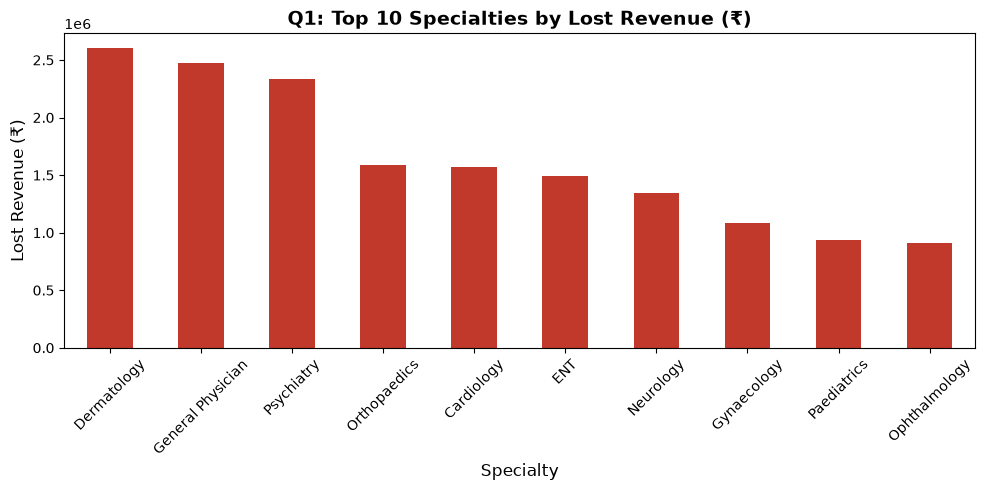

In [76]:

# SECTION 5: FINANCIAL PERFORMANCE
# QUESTION 1: How much revenue is being lost to no-shows?
# ====================================================

noshow_df = resolved_df[resolved_df['appointment_status'] == 'No-Show'].copy()


fee_col = [col for col in noshow_df.columns if 'fee' in col.lower() and 'consult' in col.lower()][0]


total_lost_revenue = noshow_df[fee_col].sum()

specialty_loss = noshow_df.groupby('specialty_x')[fee_col].sum().sort_values(ascending=False)

print(f"--- TOTAL REVENUE LOST DUE TO NO-SHOWS: ₹{total_lost_revenue:,.2f} ---")
print("\n--- Top 5 Specialties Losing the Most Revenue (₹) ---")
print(specialty_loss.head())

plt.figure(figsize=(10, 5))
specialty_loss.head(10).plot(kind='bar', color='#c0392b') 

plt.title('Q1: Top 10 Specialties by Lost Revenue (₹)', fontsize=14, fontweight='bold')
plt.xlabel('Specialty', fontsize=12)
plt.ylabel('Lost Revenue (₹)', fontsize=12)
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

--- Average Revenue by Specialty and Appointment Type (₹) ---
appointment_type   Home Visit  In-Clinic  Video Consult
specialty_x                                            
Cardiology            2863.29    1878.64        1573.14
Dermatology           1901.56    1274.97        1087.90
ENT                   1752.33    1164.54         992.10
Endocrinology         2644.18    1758.83        1579.26
Gastroenterology      2767.52    1853.60        1575.35
General Physician      925.26     611.14         533.06
Gynaecology           2170.50    1475.18        1262.94
Neurology             3039.42    2013.70        1637.61
Ophthalmology         2179.95    1421.43        1132.76
Orthopaedics          2321.43    1497.62        1281.35
Paediatrics           1371.99     917.73         819.91
Psychiatry            3720.49    2588.93        2000.61
Pulmonology           2580.01    1776.96        1472.81
Urology               2931.22    1957.37        1538.08


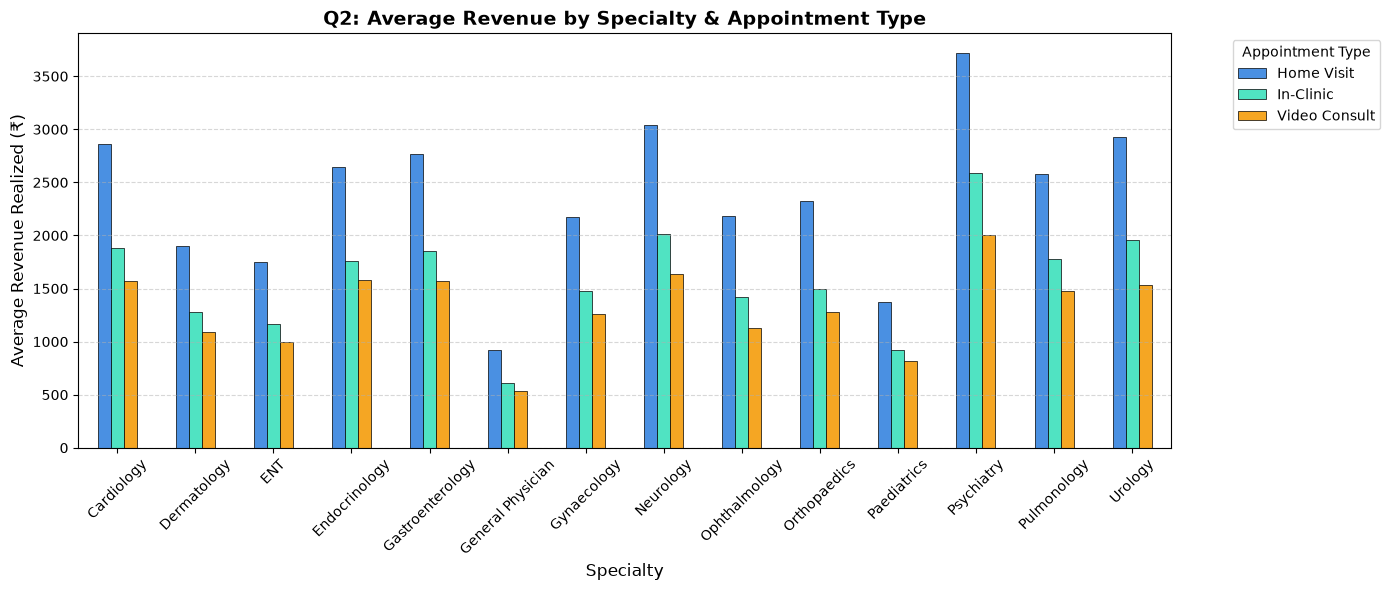

In [77]:
# ====================================================
# SECTION 5: FINANCIAL PERFORMANCE
# QUESTION 2: How does average revenue vary across specialties and appointment types?
# ====================================================

completed_df = df_merged[df_merged['appointment_status'] == 'Completed'].copy()


avg_rev_spec_type = completed_df.groupby(['specialty_x', 'appointment_type'])['revenue_realized'].mean().unstack()

print("--- Average Revenue by Specialty and Appointment Type (₹) ---")
print(avg_rev_spec_type.round(2))


premium_colors = ['#4A90E2', '#50E3C2', '#F5A623']

avg_rev_spec_type.plot(
    kind='bar', 
    figsize=(14, 6), 
    color=premium_colors, 
    edgecolor='black',
    linewidth=0.5 
)


plt.title('Q2: Average Revenue by Specialty & Appointment Type', fontsize=14, fontweight='bold')
plt.xlabel('Specialty', fontsize=12)
plt.ylabel('Average Revenue Realized (₹)', fontsize=12)


plt.legend(title='Appointment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5) 


plt.tight_layout()
plt.show()


--- Top 5 Revenue Generating Cities (₹) ---
city_x
Bengaluru    ₹9,990,616.00
Delhi        ₹9,958,247.00
Mumbai       ₹8,989,613.00
Hyderabad    ₹7,503,245.00
Chennai      ₹7,188,473.00
Name: revenue_realized, dtype: str

--- Payment Mode Mix (%) ---
payment_mode
Insurance      21.06%
Debit Card      13.3%
Net Banking     13.3%
Apollo Pay     13.25%
UPI            13.13%
Credit Card    13.05%
Cash           12.91%
Name: proportion, dtype: str


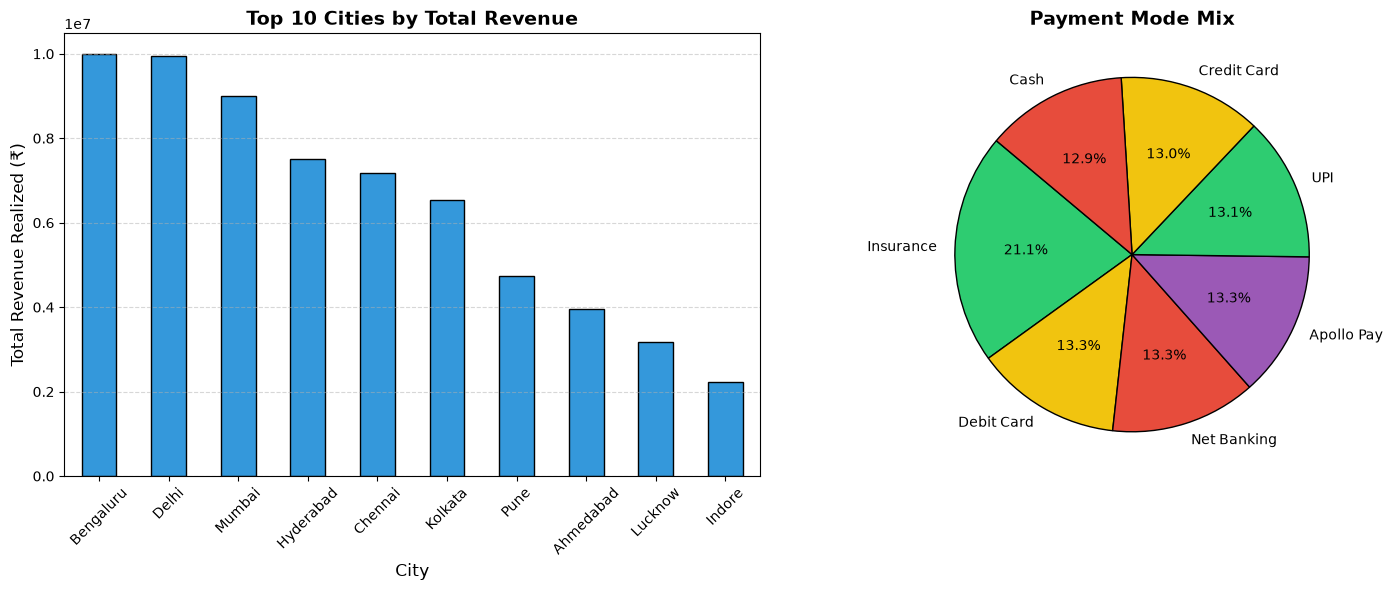

In [ ]:
# ====================================================
# SECTION 5: FINANCIAL PERFORMANCE
# QUESTION 3: Which cities generate the most revenue and what is the payment mode mix?
# ====================================================

completed_df = df_merged[df_merged['appointment_status'] == 'Completed'].copy()


city_col = 'city_x' if 'city_x' in completed_df.columns else 'city'
city_revenue = completed_df.groupby(city_col)['revenue_realized'].sum().sort_values(ascending=False)


payment_mix = completed_df['payment_mode'].value_counts(normalize=True) * 100

print("--- Top 5 Revenue Generating Cities (₹) ---")
print(city_revenue.head(5).apply(lambda x: f"₹{x:,.2f}"))
print("\n--- Payment Mode Mix (%) ---")
print(payment_mix.round(2).astype(str) + '%')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


city_revenue.head(10).plot(
    kind='bar', 
    ax=axes[0], 
    color='#3498db',
    edgecolor='black'
)
axes[0].set_title('Top 10 Cities by Total Revenue', fontsize=14, fontweight='bold')
axes[0].set_xlabel('City', fontsize=12)
axes[0].set_ylabel('Total Revenue Realized (₹)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)



payment_colors = ['#2ecc71', '#f1c40f', '#e74c3c', '#9b59b6'] 
axes[1].pie(
    payment_mix, 
    labels=payment_mix.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=payment_colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axes[1].set_title('Payment Mode Mix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('') 


plt.tight_layout()
plt.show()

--- Average Out-of-Pocket Expense (₹) ---
insurance_coverage
No     ₹1,562.82
Yes      ₹859.18
Name: patient_out_of_pocket, dtype: str


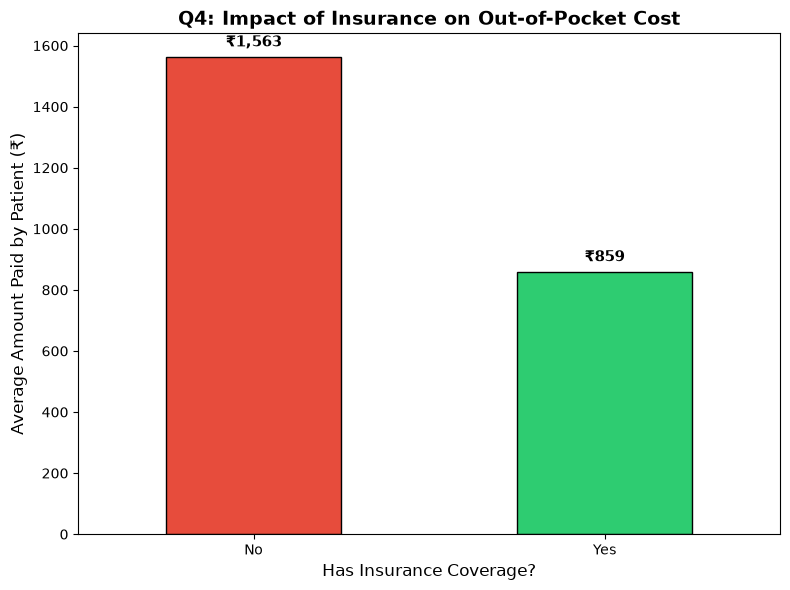

In [78]:
# ====================================================
# SECTION 5: FINANCIAL PERFORMANCE
# QUESTION 4: How does insurance coverage affect what patients pay out of pocket?

completed_df = df_merged[df_merged['appointment_status'] == 'Completed'].copy()

oop_insurance = completed_df.groupby('insurance_coverage')['patient_out_of_pocket'].mean()

print("--- Average Out-of-Pocket Expense (₹) ---")
print(oop_insurance.round(2).apply(lambda x: f"₹{x:,.2f}"))

plt.figure(figsize=(8, 6))


colors = ['#e74c3c', '#2ecc71']

bars = oop_insurance.plot(
    kind='bar', 
    color=colors,
    edgecolor='black'
)

plt.title('Q4: Impact of Insurance on Out-of-Pocket Cost', fontsize=14, fontweight='bold')
plt.xlabel('Has Insurance Coverage?', fontsize=12)
plt.ylabel('Average Amount Paid by Patient (₹)', fontsize=12)
plt.xticks(rotation=0) 

for p in bars.patches:
    bars.annotate(f'₹{p.get_height():,.0f}', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='bottom', 
                  fontsize=11, fontweight='bold', color='black', xytext=(0, 5), 
                  textcoords='offset points')


plt.tight_layout()
plt.show()

--- Bottom 5 Specialties (Lowest Utilisation %) ---
specialty_x
Psychiatry       76.18
Ophthalmology    76.19
ENT              76.33
Pulmonology      76.35
Dermatology      76.42
Name: doctor_utilization_pct, dtype: float64

--- Top 5 Specialties (Highest Utilisation %) ---
specialty_x
Paediatrics         76.66
Gynaecology         76.80
Cardiology          76.81
Endocrinology       77.15
Gastroenterology    77.26
Name: doctor_utilization_pct, dtype: float64


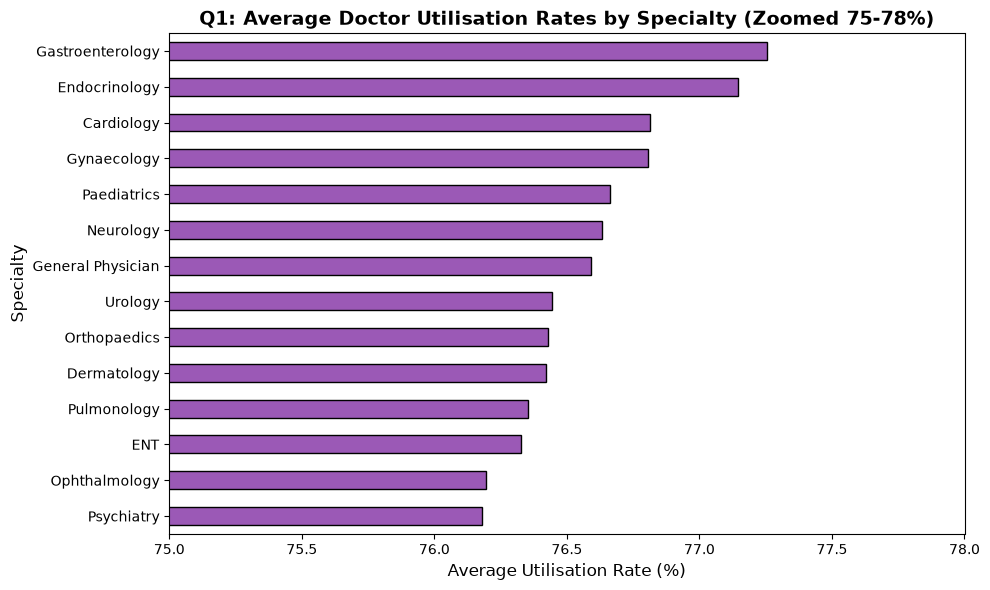

In [79]:
# ====================================================
# SECTION 6: DOCTOR UTILISATION AND SERVICE QUALITY
# QUESTION 1: Which specialties have the highest and lowest doctor utilisation rates?

completed_df = df_merged[df_merged['appointment_status'] == 'Completed'].copy()


util_rate = completed_df.groupby('specialty_x')['doctor_utilization_pct'].mean().sort_values(ascending=True)

print("--- Bottom 5 Specialties (Lowest Utilisation %) ---")
print(util_rate.head(5).round(2))
print("\n--- Top 5 Specialties (Highest Utilisation %) ---")
print(util_rate.tail(5).round(2))

plt.figure(figsize=(10, 6))

util_rate.plot(
    kind='barh', 
    color='#9b59b6', 
    edgecolor='black'
)
plt.xlim(75, 78)
plt.title('Q1: Average Doctor Utilisation Rates by Specialty (Zoomed 75-78%)', fontsize=14, fontweight='bold')
plt.xlabel('Average Utilisation Rate (%)', fontsize=12)
plt.ylabel('Specialty', fontsize=12)
plt.tight_layout()
plt.show()

--- Top 5 Specialties with Longest Wait Times (Minutes) ---
specialty_x
Ophthalmology    12.02
Urology          11.91
Dermatology      11.77
Orthopaedics     11.70
Neurology        11.64
Name: wait_time_minutes, dtype: float64

---  Average Wait Time by Time of Day (Minutes) ---
time_of_day
Morning      11.55
Afternoon    11.55
Evening      11.55
Name: wait_time_minutes, dtype: float64


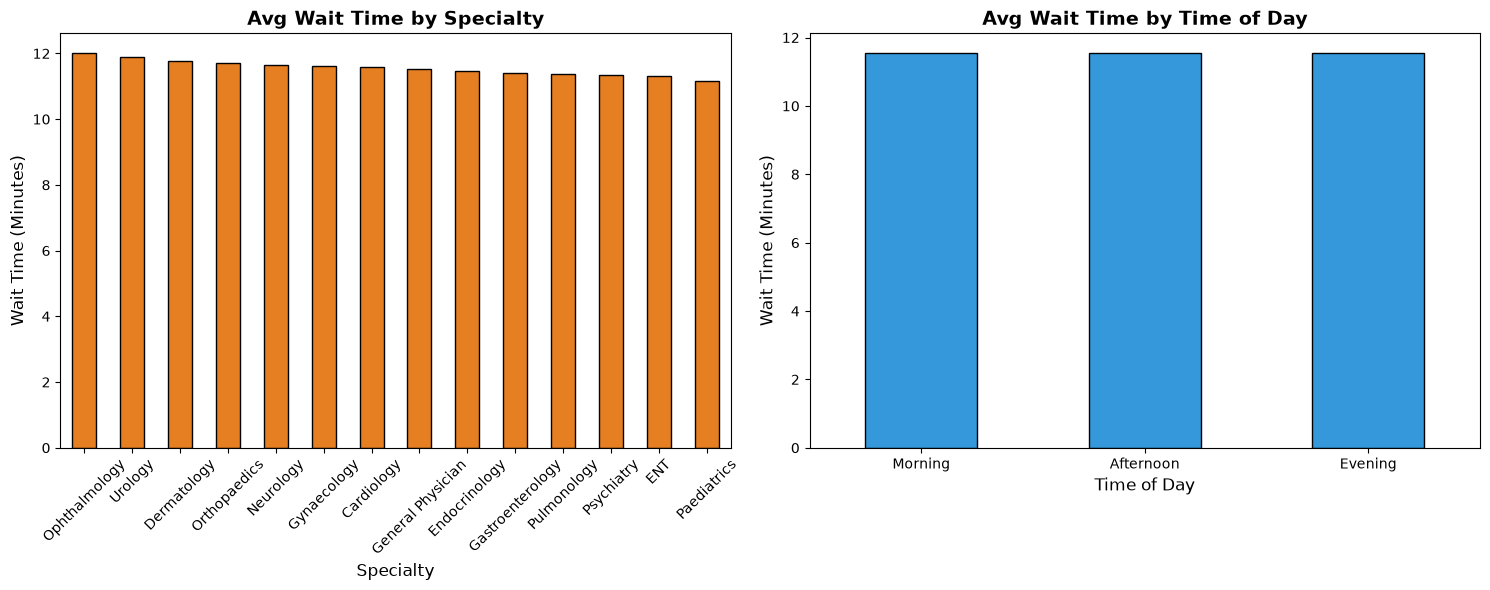

In [81]:
# ====================================================
# SECTION 6: DOCTOR UTILISATION AND SERVICE QUALITY
# QUESTION 2: How long are patients waiting and does it vary by specialty or time of day?
# ====================================================
completed_df = df_merged[df_merged['appointment_status'] == 'Completed'].copy()

wait_specialty = completed_df.groupby('specialty_x')['wait_time_minutes'].mean().sort_values(ascending=False)


wait_time_day = completed_df.groupby('time_of_day')['wait_time_minutes'].mean()


time_order = ['Morning', 'Afternoon', 'Evening']
wait_time_day = wait_time_day.reindex([t for t in time_order if t in wait_time_day.index])

print("--- Top 5 Specialties with Longest Wait Times (Minutes) ---")
print(wait_specialty.head(5).round(2))
print("\n---  Average Wait Time by Time of Day (Minutes) ---")
print(wait_time_day.round(2))


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


wait_specialty.plot(
    kind='bar', 
    ax=axes[0], 
    color='#e67e22', 
    edgecolor='black'
)
axes[0].set_title('Avg Wait Time by Specialty', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Specialty', fontsize=12)
axes[0].set_ylabel('Wait Time (Minutes)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)


wait_time_day.plot(
    kind='bar', 
    ax=axes[1], 
    color='#3498db', 
    edgecolor='black'
)
axes[1].set_title('Avg Wait Time by Time of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time of Day', fontsize=12)
axes[1].set_ylabel('Wait Time (Minutes)', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


--- Correlation Score: -0.0035 ---
 INSIGHT: The score is very close to 0! This indicates there is NO relationship between consultation time and patient satisfaction.
A longer consultation does not guarantee a higher satisfaction rating.


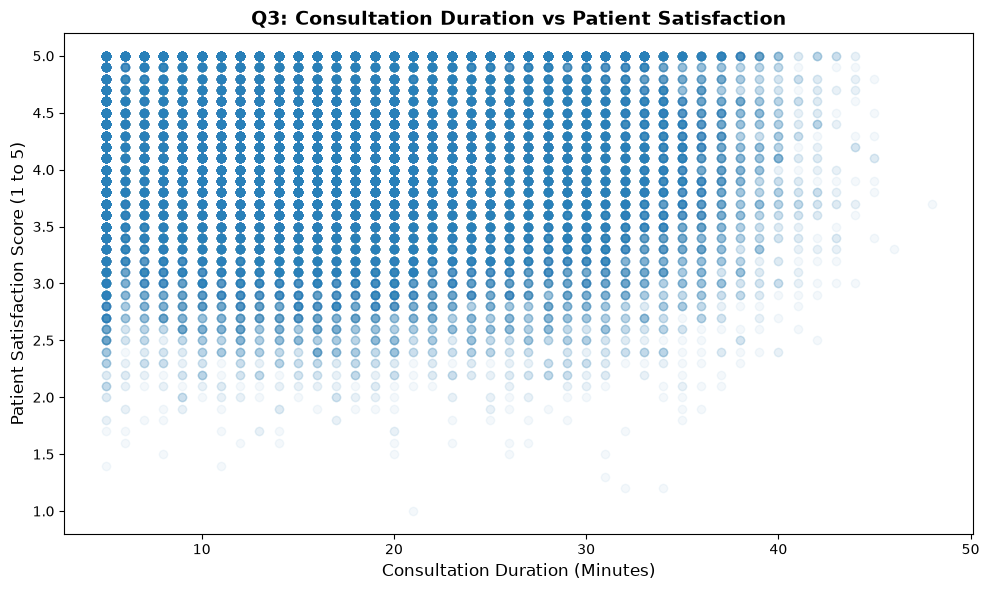

In [82]:
# ====================================================
# SECTION 6: DOCTOR UTILISATION AND SERVICE QUALITY
# QUESTION 3: Is there a relationship between consultation duration and patient satisfaction?
# ====================================================
completed_df = df_merged[df_merged['appointment_status'] == 'Completed'].copy()

correlation = completed_df['consultation_duration_min'].corr(completed_df['patient_satisfaction_score'])

print(f"--- Correlation Score: {correlation:.4f} ---")
if abs(correlation) < 0.1:
    print(" INSIGHT: The score is very close to 0! This indicates there is NO relationship between consultation time and patient satisfaction.")
    print("A longer consultation does not guarantee a higher satisfaction rating.")


plt.figure(figsize=(10, 6))


plt.scatter(
    completed_df['consultation_duration_min'], 
    completed_df['patient_satisfaction_score'], 
    alpha=0.05, 
    color='#2980b9' 
)


plt.title('Q3: Consultation Duration vs Patient Satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Consultation Duration (Minutes)', fontsize=12)
plt.ylabel('Patient Satisfaction Score (1 to 5)', fontsize=12)


plt.tight_layout()
plt.show()

--- Average Consultation Fee by Experience (Top 5 Years) ---
experience_years
2    ₹1,336.19
3    ₹1,101.00
4    ₹1,305.33
5    ₹1,254.50
6    ₹1,677.00
Name: consultation_fee_x, dtype: str


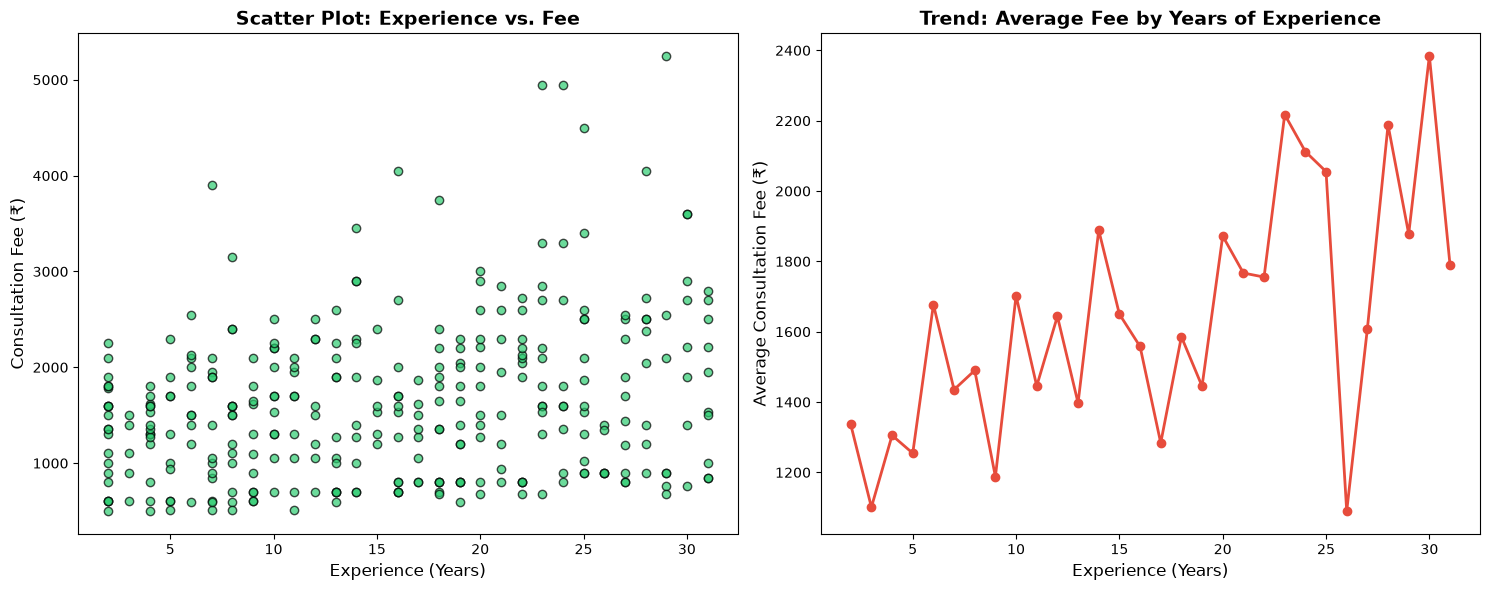

In [84]:
# ====================================================
# SECTION 6: DOCTOR UTILISATION AND SERVICE QUALITY
# QUESTION 4: How does doctor experience relate to the fee charged?

unique_doctors = df_merged.drop_duplicates(subset=['doctor_id']).copy()


fee_col = [col for col in unique_doctors.columns if 'fee' in col.lower() and 'consult' in col.lower()][0]


avg_fee_by_exp = unique_doctors.groupby('experience_years')[fee_col].mean()

print("--- Average Consultation Fee by Experience (Top 5 Years) ---")
print(avg_fee_by_exp.head().apply(lambda x: f"₹{x:,.2f}"))


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


axes[0].scatter(
    unique_doctors['experience_years'], 
    unique_doctors[fee_col], 
    alpha=0.7, 
    color='#2ecc71',
    edgecolor='black'
)
axes[0].set_title('Scatter Plot: Experience vs. Fee', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Experience (Years)', fontsize=12)
axes[0].set_ylabel('Consultation Fee (₹)', fontsize=12)


axes[1].plot(
    avg_fee_by_exp.index, 
    avg_fee_by_exp.values, 
    marker='o', 
    color='#e74c3c', 
    linewidth=2
)
axes[1].set_title('Trend: Average Fee by Years of Experience', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Experience (Years)', fontsize=12)
axes[1].set_ylabel('Average Consultation Fee (₹)', fontsize=12)


plt.tight_layout()
plt.show()